На основе подготовленной для нейросети таблицы данных с HeadHunter создайте 6 архитектур нейросетей, поэкспериментируйте с гиперпараметрами.
Используйте только числовые данные, текстовые не подавайте.

Результаты в конце проанализируйте.

Перед началом выполнения, пожалуйста, запустите раздел "Подготовка".

## Подготовка

In [1]:
# Работа с массивами данных
import numpy as np

# Работа с табличными данными
import pandas as pd

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Масштабирование данных
from sklearn.preprocessing import StandardScaler

# Загрузка датасетов из облака google
import gdown

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline

In [2]:
# скачиваем базу
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv', None, quiet=True)

# Чтение файла базы данных
df = pd.read_csv('hh_fixed.csv', index_col=0)

# Вывод количества резюме и числа признаков
print(df.shape)

df.head(3)

(62967, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,Город,Занятость,График,Опыт (двойное нажатие для полной версии),Последенее/нынешнее место работы,Последеняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 29 лет , родился 16 мая 1989",40000 руб.,Специалист по поддержке чата(support team) дом...,"Новороссийск , готов к переезду (Анапа, Геленд...",полная занятость,полный день,Опыт работы 3 года 9 месяцев Специалист по по...,"ООО ""Гольфстрим""",Генеральный директор,Высшее образование 2011 Международный юридиче...,26.04.2019 08:04,Не указано
1,"Мужчина , 38 лет , родился 25 мая 1980",40000 руб.,Системный администратор,"Новосибирск , м. Березовая роща , не готов к ...",полная занятость,полный день,Опыт работы 11 лет 11 месяцев Системный админ...,ООО «Завод модульных технологий»,Системный администратор,Высшее образование 2002 Новосибирский государс...,26.04.2019 04:30,Не указано
2,"Мужчина , 35 лет , родился 14 июня 1983",300000 руб.,DevOps TeamLead / DevOps архитектор,"Москва , готов к переезду , готов к редким ком...",полная занятость,полный день,Опыт работы 12 лет 11 месяцев DevOps TeamLead...,Банк ВТБ (ПАО),Начальник отдела методологии разработки (DevOp...,DevOps TeamLead / DevOps архитектор 300 000 ру...,09.04.2019 14:40,Не указано


In [3]:
# Настройка номеров столбцов

COL_SEX_AGE     = df.columns.get_loc('Пол, возраст')
COL_SALARY      = df.columns.get_loc('ЗП')
COL_POS_SEEK    = df.columns.get_loc('Ищет работу на должность:')
COL_POS_PREV    = df.columns.get_loc('Последеняя/нынешняя должность')
COL_CITY        = df.columns.get_loc('Город')
COL_EMPL        = df.columns.get_loc('Занятость')
COL_SCHED       = df.columns.get_loc('График')
COL_EXP         = df.columns.get_loc('Опыт (двойное нажатие для полной версии)')
COL_EDU         = df.columns.get_loc('Образование и ВУЗ')
COL_UPDATED     = df.columns.get_loc('Обновление резюме')

In [4]:
# Замена концов строк на пробелы, удаление символа с кодом 0xA0
# обрезка краевых пробелов, приведение к нижнему регистру

def purify(x):
    if isinstance(x, str):                # Если значение - строка:
        x = x.replace('\n', ' ').replace('\xa0', '').strip().lower()
    return x

In [5]:
# Выделение подстроки вида ДД.ММ.ГГГГ и возвращение значения года

def extract_year(x):
    try:
        return int(re.search(r'\d\d.\d\d.(\d{4})', x)[1])   # Ожидается строка вида 'dd.mm.yyyy ...'

    except (IndexError, TypeError, ValueError):
        return 0

In [6]:
### Параметрические данные для функций разбора ###

# Курсы валют для зарплат
currency_rate = {'usd'    : 65.,
                 'kzt'    : 0.17,
                 'грн'    : 2.6,
                 'белруб' : 30.5,
                 'eur'    : 70.,
                 'kgs'    : 0.9,
                 'сум'    : 0.007,
                 'azn'    : 37.5
                }

# Списки и словари для разбиения на классы
# Для ускорения работы добавлен счетчик классов, который будет вычислен ниже

# Список порогов возраста
age_class = [0, [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]]

# Список порогов опыта работы в месяцах
experience_class = [0, [7, 13, 25, 37, 61, 97, 121, 157, 193, 241]]

# Классы городов
city_class = [0,
              {'москва'          : 0,
               'санкт-петербург' : 1,
               'новосибирск'     : 2,
               'екатеринбург'    : 2,
               'нижний новгород' : 2,
               'казань'          : 2,
               'челябинск'       : 2,
               'омск'            : 2,
               'самара'          : 2,
               'ростов-на-дону'  : 2,
               'уфа'             : 2,
               'красноярск'      : 2,
               'пермь'           : 2,
               'воронеж'         : 2,
               'волгоград'       : 2,
               'прочие города'   : 3
              }]

# Классы занятости
employment_class = [0,
                    {'стажировка'          : 0,
                     'частичная занятость' : 1,
                     'проектная работа'    : 2,
                     'полная занятость'    : 3
                    }]

# Классы графика работы
schedule_class = [0,
                  {'гибкий график'         : 0,
                   'полный день'           : 1,
                   'сменный график'        : 2,
                   'удаленная работа'      : 3
                  }]

# Классы образования
education_class = [0,
                   {'высшее образование'   : 0,
                    'higher education'     : 0,
                    'среднее специальное'  : 1,
                    'неоконченное высшее'  : 2,
                    'среднее образование'  : 3
                   }]


In [7]:
# Вычисление счетчиков для данных разбиения

for class_desc in [age_class,
                   experience_class,
                   city_class,
                   employment_class,
                   schedule_class,
                   education_class]:
    if isinstance(class_desc[1], list):
        class_desc[0] = len(class_desc[1]) + 1
    else:
        class_desc[0] = max(class_desc[1].values()) + 1

In [8]:
 # Получение one hot encoding представления значения класса

 def int_to_ohe(arg, class_list):

    # Определение размерности выходного вектора
    num_classes = class_list[0]

    # Поиск верного интервала для входного значения
    for i in range(num_classes - 1):
        if arg < class_list[1][i]:
            cls = i                       # Интервал найден - назначение класса
            break
    else:                                 # Внимание: for/else
        cls = num_classes - 1             # Интервал не найден - последний класс

    # Возврат в виде one hot encoding-вектора
    return utils.to_categorical(cls, num_classes)

In [9]:
# Общая функция преобразования строки к multi-вектору
# На входе данные и словарь сопоставления подстрок классам

def str_to_multi(arg, class_dict):
    # Определение размерности выходного вектора
    num_classes = class_dict[0]

    # Создание нулевого вектора
    result = np.zeros(num_classes)

    # Поиск значения в словаре и, если найдено,
    # выставление 1. на нужной позиции
    for value, cls in class_dict[1].items():
        if value in arg:
            result[cls] = 1.

    return result

In [10]:
# Разбор значений пола, возраста

base_update_year = 2019

def extract_sex_age_years(arg):
    # Ожидается, что значение содержит "мужчина" или "женщина"
    # Если "мужчина" - результат 1., иначе 0.
    sex = 1. if 'муж' in arg else 0.

    try:
        # Выделение года и вычисление возраста
        years = base_update_year - int(re.search(r'\d{4}', arg)[0])

    except (IndexError, TypeError, ValueError):
        # В случае ошибки год равен 0
        years = 0

    return sex, years

In [11]:
# Преобразование значения возраста в one hot encoding

def age_years_to_ohe(arg):
    return int_to_ohe(arg, age_class)

In [12]:
# Преобразование данных об опыте работы в one hot encoding

def experience_months_to_ohe(arg):
    return int_to_ohe(arg, experience_class)

In [13]:
# Разбор значения зарплаты

def extract_salary(arg):
    try:
        # Выделение числа и преобразование к float
        value = float(re.search(r'\d+', arg)[0])

        # Поиск символа валюты в строке, и, если найдено,
        # приведение к рублю по курсу валюты
        for currency, rate in currency_rate.items():
            if currency in arg:
                value *= rate
                break

    except TypeError:
        # Если не получилось выделить число - вернуть 0
        value = 0.

    return value / 1000.                  # В тысячах рублей

In [14]:
# Разбор данных о городe и преобразование в one hot encoding

def extract_city_to_ohe(arg):
    # Определение размерности выходного вектора
    num_classes = city_class[0]

    # Разбивка на слова
    split_array = re.split(r'[ ,.:()?!]', arg)

    # Поиск города в строке и присвоение ему класса
    for word in split_array:
        city_cls = city_class[1].get(word, -1)
        if city_cls >= 0:
            break
    else:                                 # Внимание: for/else
        # Город не в city_class - значит его класс "прочие города"
        city_cls = num_classes - 1

    # Возврат в виде one hot encoding-вектора
    return utils.to_categorical(city_cls, num_classes)

In [15]:
# Разбор данных о желаемой занятости и преобразование в multi

def extract_employment_to_multi(arg):
    return str_to_multi(arg, employment_class)

In [16]:
# Разбор данных о желаемом графике работы и преобразование в multi

def extract_schedule_to_multi(arg):
    return str_to_multi(arg, schedule_class)

In [17]:
# Разбор данных об образовании и преобразование в multi

def extract_education_to_multi(arg):
    result = str_to_multi(arg, education_class)

    # Поправка: неоконченное высшее не может быть одновременно с высшим
    if result[2] > 0.:
        result[0] = 0.

    return result

In [18]:
# Разбор данных об опыте работы - результат в месяцах

def extract_experience_months(arg):
    try:
        # Выделение количества лет, преобразование в int
        years = int(re.search(r'(\d+)\s+(год.?|лет)', arg)[1])

    except (IndexError, TypeError, ValueError):
        # Неудача - количество лет равно 0
        years = 0

    try:
        # Выделение количества месяцев, преобразование в int
        months = int(re.search(r'(\d+)\s+месяц', arg)[1])

    except (IndexError, TypeError, ValueError):
        # Неудача - количество месяцев равно 0
        months = 0

    # Возврат результата в месяцах
    return years * 12 + months

Функции подготовки выборок

In [19]:
def extract_row_data(row):

    # Извлечение и преобразование данных
    sex, age = extract_sex_age_years(row[COL_SEX_AGE])      # Пол, возраст
    sex_vec = np.array([sex])                               # Пол в виде вектора
    age_ohe = age_years_to_ohe(age)                         # Возраст в one hot encoding
    city_ohe = extract_city_to_ohe(row[COL_CITY])           # Город
    empl_multi = extract_employment_to_multi(row[COL_EMPL]) # Тип занятости
    sсhed_multi = extract_schedule_to_multi(row[COL_SCHED]) # График работы
    edu_multi = extract_education_to_multi(row[COL_EDU])    # Образование
    exp_months = extract_experience_months(row[COL_EXP])    # Опыт работы в месяцах
    exp_ohe = experience_months_to_ohe(exp_months)          # Опыт работы в one hot encoding
    salary = extract_salary(row[COL_SALARY])                # Зарплата в тысячах рублей
    salary_vec = np.array([salary])                         # Зарплата в виде вектора

    # Объединение всех входных данных в один общий вектор
    x_data = np.hstack([sex_vec,
                        age_ohe,
                        city_ohe,
                        empl_multi,
                        sсhed_multi,
                        edu_multi,
                        exp_ohe])

    # Возврат входных данных и выходных (зарплаты)
    return x_data, salary_vec


# Создание общей выборки
def construct_train_data(row_list):
    x_data = []
    y_data = []

    for row in row_list:
        x, y = extract_row_data(row)
        if y[0] > 0:                      # Данные добавляются, только если есть зарплата
            x_data.append(x)
            y_data.append(y)

    return np.array(x_data), np.array(y_data)

In [20]:
# Формирование выборки из загруженного набора данных
x_train_01, y_train = construct_train_data(df.values)

In [21]:
# Форма наборов параметров и зарплат
print(x_train_01.shape)
print(y_train.shape)

# Пример обработанных данных
n = 0
print(x_train_01[n])
print(y_train[n])

(62967, 39)
(62967, 1)
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[40.]


Функция отрисовки графика истории обучения

In [22]:
def plot_history(history):
    plt.plot(history.history['mae'],
            label='Средняя абсолютная ошибка на обучающем наборе')
    plt.plot(history.history['val_mae'],
            label='Средняя абсолютная ошибка на проверочном наборе')
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя абсолютная ошибка')
    plt.legend()
    plt.show()

In [25]:
from sklearn.model_selection import train_test_split

# Масштабируем входные числовые признаки
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(x_train_01)

# Масштабируем целевые значения (зарплату)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_train)

# Разбиваем на обучающую (80%) и валидационную (20%) выборки
X_train, X_val, y_train_scaled, y_val_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер обучающей выборки: (50373, 39)
Размер валидационной выборки: (12594, 39)


In [26]:
# Архитектура №1 — базовая (1 скрытый слой)

model_1 = Sequential(name="Model_1_Basic")
model_1.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model_1.add(Dense(1, activation='linear'))

model_1.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_1 = model_1.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9549 - mae: 0.6227 - val_loss: 0.8493 - val_mae: 0.5987
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8980 - mae: 0.5893 - val_loss: 0.8407 - val_mae: 0.5840
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8904 - mae: 0.5838 - val_loss: 0.8358 - val_mae: 0.5802
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8867 - mae: 0.5819 - val_loss: 0.8310 - val_mae: 0.5793
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8841 - mae: 0.5805 - val_loss: 0.8303 - val_mae: 0.5832
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8820 - mae: 0.5793 - val_loss: 0.8296 - val_mae: 0.5769
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8801 - mae: 0.5779 - val_loss: 0.8312 - val_mae: 0.5831
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8808 - mae: 0.5789 - val_loss: 0.8298 - val_mae: 0.5794
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8781 

In [27]:
# Архитектура №2 — глубокая сеть

model_2 = Sequential(name="Model_2_Deep")
model_2.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_2.add(Dense(256, activation='relu'))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(64, activation='relu'))
model_2.add(Dense(1, activation='linear'))

model_2.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_2 = model_2.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.9035 - mae: 0.5879 - val_loss: 0.8324 - val_mae: 0.5688
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.8843 - mae: 0.5784 - val_loss: 0.8285 - val_mae: 0.5839
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8802 - mae: 0.5767 - val_loss: 0.8288 - val_mae: 0.5897
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8788 - mae: 0.5757 - val_loss: 0.8309 - val_mae: 0.5940
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8766 - mae: 0.5751 - val_loss: 0.8301 - val_mae: 0.5774
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8750 - mae: 0.5740 - val_loss: 0.8258 - val_mae: 0.5785
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8727 - mae: 0.5738 - val_loss: 0.8305 - val_mae: 0.5613
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8716 - mae: 0.5730 - val_loss: 0.8305 - val_mae: 0.5767
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - l

In [28]:
# Архитектура №3 — с Dropout для регуляризации

model_3 = Sequential(name="Model_3_WithDropout")
model_3.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_3.add(Dropout(0.3))
model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(0.3))
model_3.add(Dense(128, activation='relu'))
model_3.add(Dropout(0.2))
model_3.add(Dense(1, activation='linear'))

model_3.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_3 = model_3.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.9543 - mae: 0.6166 - val_loss: 0.8487 - val_mae: 0.5857
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9092 - mae: 0.5945 - val_loss: 0.8372 - val_mae: 0.5870
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9000 - mae: 0.5886 - val_loss: 0.8392 - val_mae: 0.5993
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8925 - mae: 0.5853 - val_loss: 0.8332 - val_mae: 0.5979
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8947 - mae: 0.5841 - val_loss: 0.8357 - val_mae: 0.5996
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8898 - mae: 0.5829 - val_loss: 0.8384 - val_mae: 0.5867
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8877 - mae: 0.5815 - val_loss: 0.8323 - val_mae: 0.5978
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8869 - mae: 0.5819 - val_loss: 0.8279 - val_mae: 0.5753
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - l

In [29]:
# Архитектура №4 — с BatchNormalization

model_4 = Sequential(name="Model_4_WithBatchNorm")
model_4.add(BatchNormalization(input_dim=X_train.shape[1]))
model_4.add(Dense(128, activation='relu'))
model_4.add(BatchNormalization())
model_4.add(Dense(256, activation='relu'))
model_4.add(BatchNormalization())
model_4.add(Dense(128, activation='relu'))
model_4.add(Dense(1, activation='linear'))

model_4.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_4 = model_4.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.0124 - mae: 0.6447 - val_loss: 0.8795 - val_mae: 0.5904
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9323 - mae: 0.6079 - val_loss: 0.8554 - val_mae: 0.5819
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9090 - mae: 0.5953 - val_loss: 0.8654 - val_mae: 0.6067
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8950 - mae: 0.5885 - val_loss: 0.8458 - val_mae: 0.5918
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8900 - mae: 0.5868 - val_loss: 0.8492 - val_mae: 0.5762
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8821 - mae: 0.5813 - val_loss: 0.8415 - val_mae: 0.5803
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8758 - mae: 0.5780 - val_loss: 0.8437 - val_mae: 0.5897
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8761 - mae: 0.5781 - val_loss: 0.8418 - val_mae: 0.5850
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8750

In [32]:
# Архитектура №5 — узкая сеть (эффективная)

model_5 = Sequential(name="Model_5_Narrow")
model_5.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model_5.add(Dense(16, activation='relu'))
model_5.add(Dense(8, activation='relu'))
model_5.add(Dense(1, activation='linear'))

model_5.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_5 = model_5.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9249 - mae: 0.6010 - val_loss: 0.8404 - val_mae: 0.5881
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8888 - mae: 0.5813 - val_loss: 0.8329 - val_mae: 0.5877
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8828 - mae: 0.5780 - val_loss: 0.8282 - val_mae: 0.5795
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8808 - mae: 0.5771 - val_loss: 0.8297 - val_mae: 0.5877
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8793 - mae: 0.5763 - val_loss: 0.8301 - val_mae: 0.5861
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8779 - mae: 0.5761 - val_loss: 0.8287 - val_mae: 0.5733
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8773 - mae: 0.5755 - val_loss: 0.8269 - val_mae: 0.5750
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8763 - mae: 0.5747 - val_loss: 0.8261 - val_mae: 0.5778
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

In [31]:
# Архитектура №6 — сеть с убывающим learning rate

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

model_6 = Sequential(name="Model_6_LR_Annealing")
model_6.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_6.add(Dense(128, activation='relu'))
model_6.add(Dense(64, activation='relu'))
model_6.add(Dense(32, activation='relu'))
model_6.add(Dense(1, activation='linear'))

model_6.compile(optimizer=Adam(learning_rate=0.001),
               loss='mse',
               metrics=['mae'])

history_6 = model_6.fit(X_train, y_train_scaled,
                        validation_data=(X_val, y_val_scaled),
                        epochs=20, batch_size=256, verbose=1,
                        callbacks=[reduce_lr])

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9036 - mae: 0.5880 - val_loss: 0.8305 - val_mae: 0.5835 - learning_rate: 0.0010
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8840 - mae: 0.5785 - val_loss: 0.8289 - val_mae: 0.5836 - learning_rate: 0.0010
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8810 - mae: 0.5767 - val_loss: 0.8284 - val_mae: 0.5740 - learning_rate: 0.0010
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8773 - mae: 0.5751 - val_loss: 0.8295 - val_mae: 0.5669 - learning_rate: 0.0010
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8756 - mae: 0.5751 - val_loss: 0.8260 - val_mae: 0.5644 - learning_rate: 0.0010
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8729 - mae: 0.5736 - val_loss: 0.8253 - val_mae: 0.5784 - learning_rate: 0.0010
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8725 - mae: 0.5725 - val_loss: 0.8261 - val_mae: 0.5815 - learning_rate: 0.0010
Epoch

In [39]:
# Анализ результатов — таблица метрик

import pandas as pd

results = []
models_list = [
    (history_1, "Базовая (1 скрытый слой)"),
    (history_2, "Глубокая (4 скрытых слоя)"),
    (history_3, "Dropout"),
    (history_4, "BatchNormalization"),
    (history_5, "Узкая (32→16→8)"),
    (history_6, "LR Annealing")
]

for i, (history, name) in enumerate(models_list, 1):
    train_mae = history.history['mae'][-1]
    val_mae = history.history['val_mae'][-1]

    # Преобразуем обратно в тысячи рублей
    train_mae_real = train_mae * scaler_y.scale_[0]
    val_mae_real = val_mae * scaler_y.scale_[0]

    results.append({
        'Модель': i,
        'Архитектура': name,
        'Train MAE (норм.)': f"{train_mae:.4f}",
        'Val MAE (норм.)': f"{val_mae:.4f}",
        'Train MAE (тыс. руб)': f"{train_mae_real:.2f}",
        'Val MAE (тыс. руб)': f"{val_mae_real:.2f}"
    })

df_results = pd.DataFrame(results)
print("=" * 90)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ 6 АРХИТЕКТУР НЕЙРОСЕТЕЙ")
print("=" * 90)
print(df_results.to_string(index=False))

СРАВНИТЕЛЬНЫЙ АНАЛИЗ 6 АРХИТЕКТУР НЕЙРОСЕТЕЙ
 Модель               Архитектура Train MAE (норм.) Val MAE (норм.) Train MAE (тыс. руб) Val MAE (тыс. руб)
      1  Базовая (1 скрытый слой)            0.5752          0.5771                41.64              41.78
      2 Глубокая (4 скрытых слоя)            0.5686          0.5757                41.16              41.67
      3                   Dropout            0.5780          0.5907                41.84              42.76
      4        BatchNormalization            0.5714          0.5834                41.37              42.23
      5           Узкая (32→16→8)            0.5727          0.5749                41.46              41.61
      6              LR Annealing            0.5649          0.5728                40.89              41.47


In [ ]:
# MSE для полного анализа
from sklearn.metrics import mean_squared_error

pred_val = model_6.predict(X_val)
mse_val = mean_squared_error(y_val_scaled, pred_val)
print(f"MSE (норм.) лучшей модели: {mse_val:.6f}")

394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MSE (норм.) лучшей модели: 0.824304


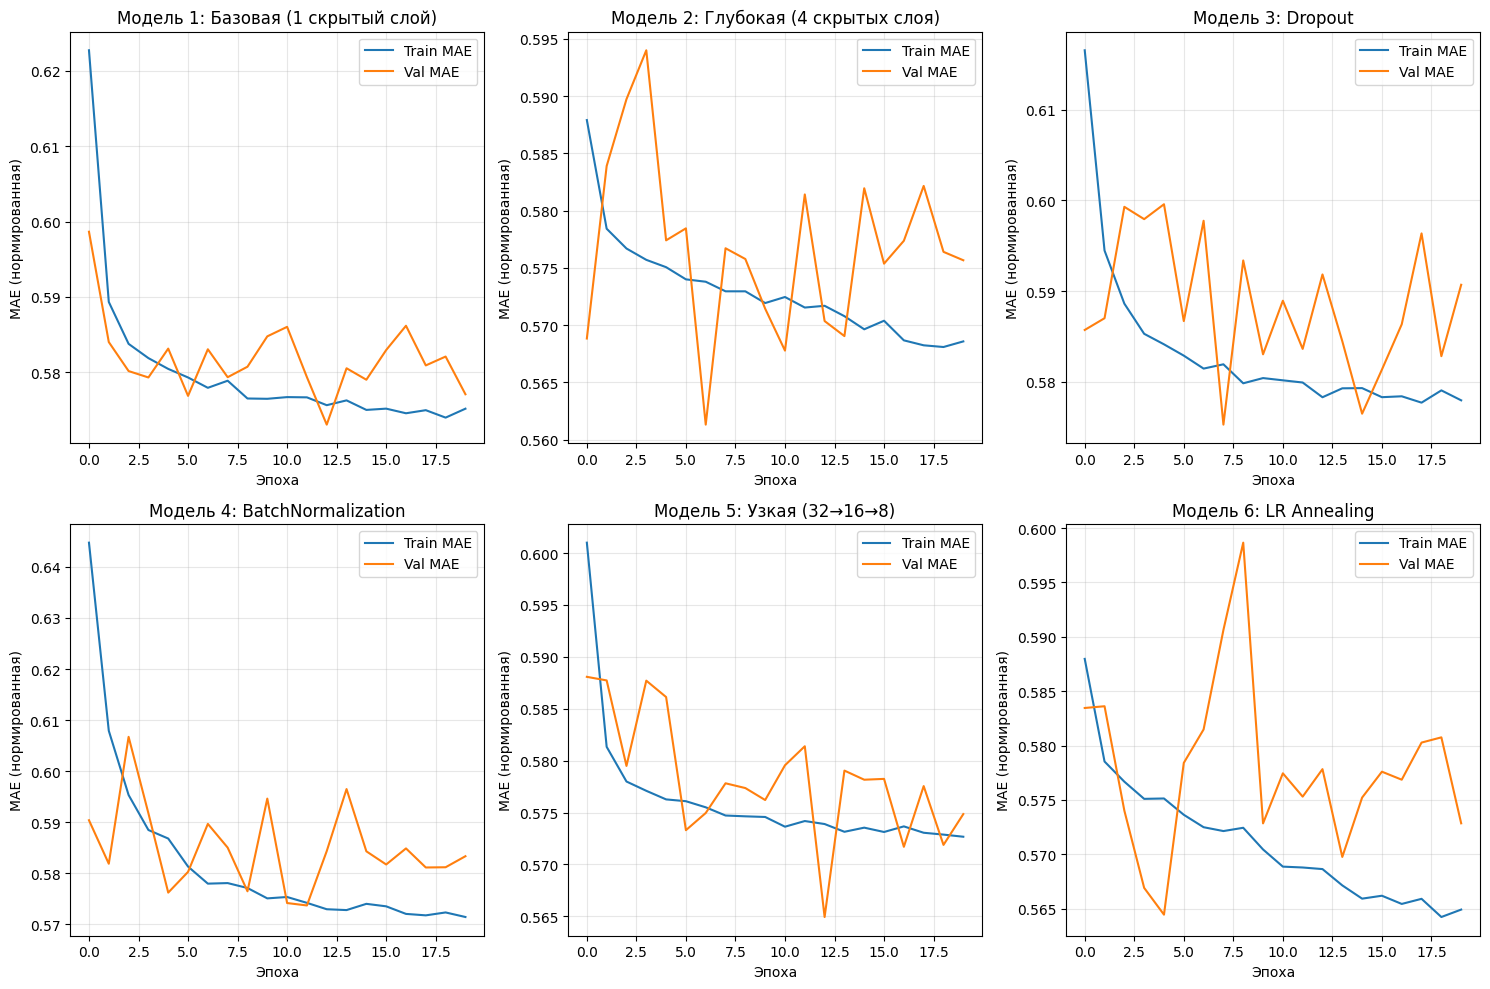

In [45]:
# Визуализация графиков обучения всех моделей

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

models_history = [
    (history_1, "Модель 1: Базовая (1 скрытый слой)"),
    (history_2, "Модель 2: Глубокая (4 скрытых слоя)"),
    (history_3, "Модель 3: Dropout"),
    (history_4, "Модель 4: BatchNormalization"),
    (history_5, "Модель 5: Узкая (32→16→8)"),
    (history_6, "Модель 6: LR Annealing")
]

for i, (history, title) in enumerate(models_history):
    axes[i].plot(history.history['mae'], label='Train MAE', linewidth=1.5)
    axes[i].plot(history.history['val_mae'], label='Val MAE', linewidth=1.5)
    axes[i].set_title(title)
    axes[i].set_xlabel('Эпоха')
    axes[i].set_ylabel('MAE (нормированная)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()